In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle
from scipy.stats import pearsonr

In [16]:
def plot_relative_policy_cost(districts, pool, tolerance_level, policy_order, policy_colors):
    fig, axs = plt.subplots(1, len(districts), figsize=(6 * len(districts), 6), sharex=True)

    for i, district in enumerate(districts):
        # Filter the dataframe for the specific district and tolerance level
        df = pd.read_csv("results/{}_pool={}.csv".format(district, pool))
        df = df[df.policy.isin(policy_order)]
        filtered_df = df[(df["unconditional_tolerance"] == tolerance_level)].copy()

        # Compute the relative policy_cost compared to the "saturation" policy
        saturation_cost = filtered_df.loc[filtered_df["policy"] == "saturation", "policy_cost"].iloc[0]
        filtered_df["relative_cost"] = filtered_df["policy_cost"] / saturation_cost

        filtered_df["policy"] = pd.Categorical(filtered_df["policy"], categories=policy_order)
        filtered_df.sort_values("policy", inplace=True)

        print(filtered_df["policy"], filtered_df["relative_cost"])


        # Make a bar graph of relative cost vs. policy
        if len(districts) >=2:
            bars = axs[i].bar(filtered_df["policy"], filtered_df["relative_cost"], color=policy_colors)
            axs[i].set_ylabel("Cost Relative to Saturation Policy")
            axs[i].set_title(f"Malawi District - {district}")
        

        # Put the relative cost values on top of each bar
            for bar, cost in zip(bars, filtered_df["relative_cost"]):
                axs[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{cost:.2f}", ha='center', va='bottom')
        else:
            bars = axs.bar(filtered_df["policy"], filtered_df["relative_cost"], color=policy_colors)
            axs.set_ylabel("Cost Relative to Saturation Policy")
            axs.set_title(f"Malawi District - {district}")

            for bar, cost in zip(bars, filtered_df["relative_cost"]):
                axs.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{cost:.2f}", ha='center', va='bottom')
        

    plt.suptitle(f"Relative Policy Cost when Unconditional Tolerance={tolerance_level}")
    plt.savefig("figs/relative_cost_{}_uncondtol={}.pdf".format("-".join(districts), tolerance_level))


1    saturation
2        binary
3     optimized
Name: policy, dtype: category
Categories (3, object): ['saturation', 'binary', 'optimized'] 1    1.00000
2    0.94492
3    0.90160
Name: relative_cost, dtype: float64
1    saturation
5        binary
2     optimized
Name: policy, dtype: category
Categories (3, object): ['saturation', 'binary', 'optimized'] 1    1.000000
5    0.915266
2    0.872303
Name: relative_cost, dtype: float64
0    saturation
4        binary
2     optimized
Name: policy, dtype: category
Categories (3, object): ['saturation', 'binary', 'optimized'] 0    1.000000
4    0.949126
2    0.912067
Name: relative_cost, dtype: float64


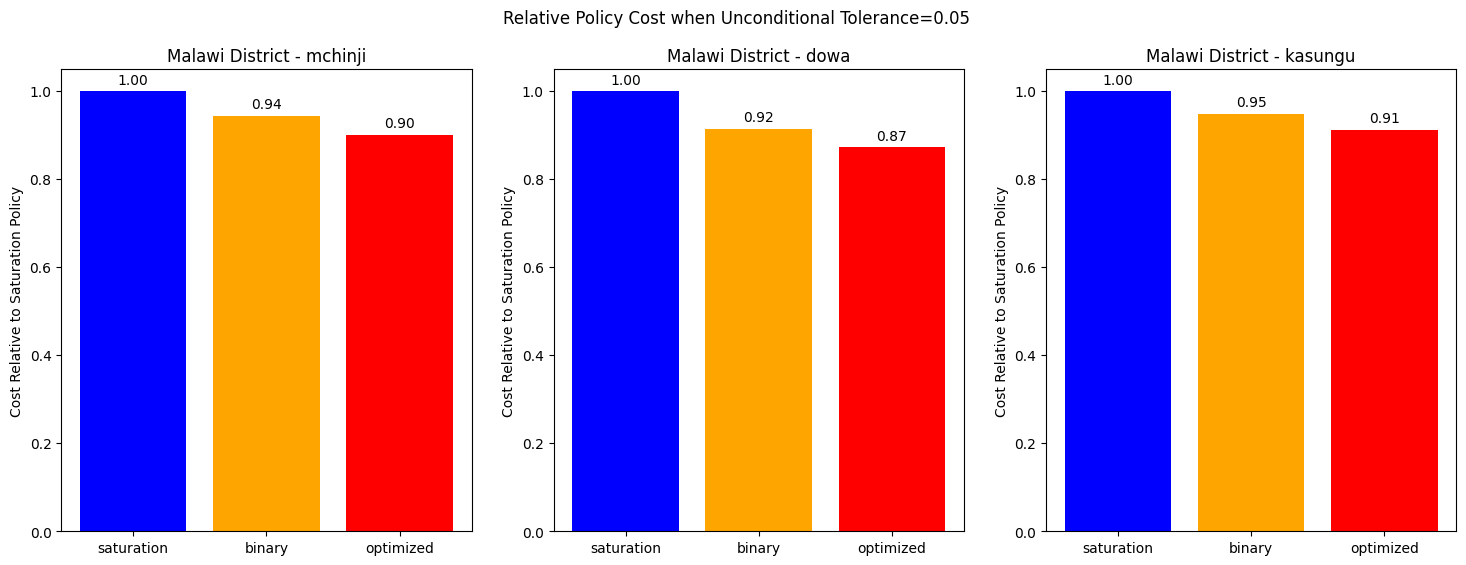

In [20]:
plot_relative_policy_cost(["mchinji", "dowa", "kasungu"], pool="central", tolerance_level=0.05, policy_order=["saturation", "binary", "optimized"], policy_colors=["blue", "orange", "red"])

0    saturation
2        binary
4     optimized
Name: policy, dtype: category
Categories (3, object): ['saturation', 'binary', 'optimized'] 0    1.000000
2    0.843723
4    0.748947
Name: relative_cost, dtype: float64
0    saturation
4        binary
2     optimized
Name: policy, dtype: category
Categories (3, object): ['saturation', 'binary', 'optimized'] 0    1.000000
4    0.852003
2    0.777029
Name: relative_cost, dtype: float64


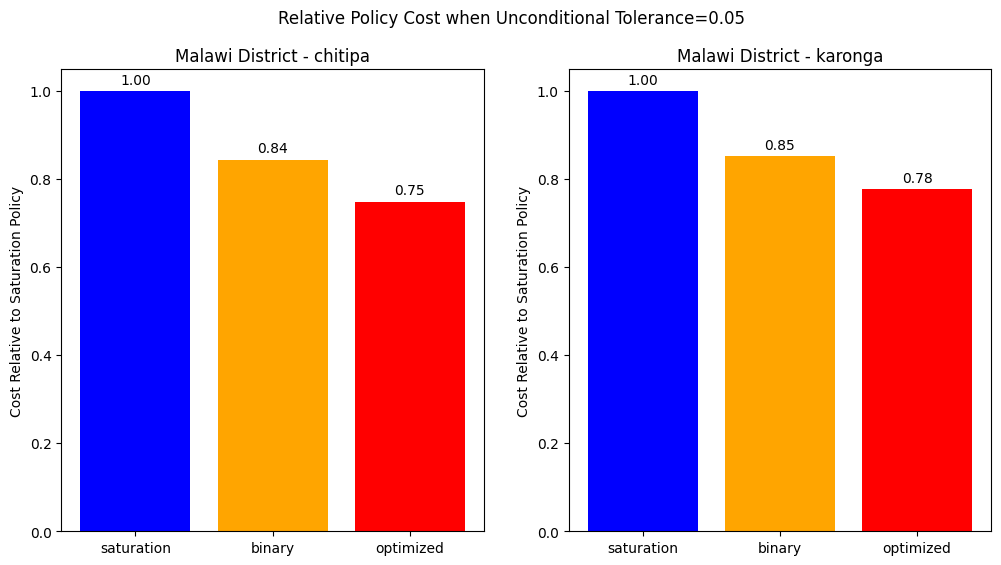

In [21]:
plot_relative_policy_cost(["chitipa","karonga"], pool="rural", tolerance_level=0.05, policy_order=["saturation", "binary", "optimized"], policy_colors=["blue", "orange", "red"])

1    saturation
3        binary
6    geographic
4     optimized
Name: policy, dtype: category
Categories (4, object): ['saturation', 'binary', 'geographic', 'optimized'] 1    1.000000
3    0.803790
6    0.897857
4    0.772752
Name: relative_cost, dtype: float64


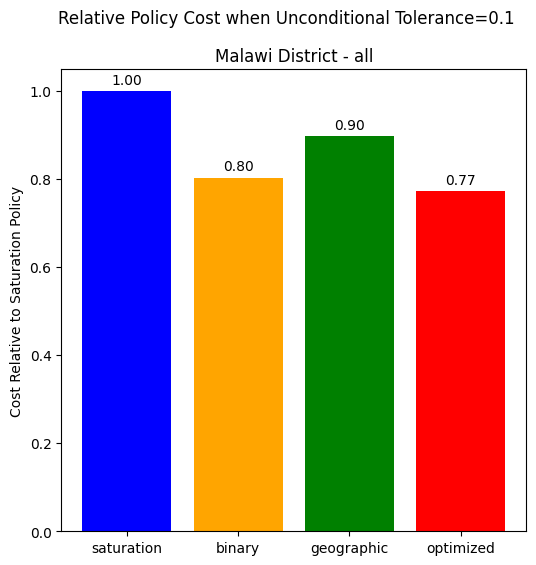

In [19]:
plot_relative_policy_cost(["all"], pool="central", tolerance_level=0.05, policy_order=["saturation", "binary", "geographic", "optimized"], policy_colors=["blue", "orange", "green", "red"])